# 04 - Chunking Comparison

## Objective

Compare the chunking strategies used by both RAG pipelines.

### Pipeline 1

- Recursive Character Chunking
- Chunk Size: 1000
- Chunk Overlap: 200

### Pipeline 2

- Section-Based Chunking
- Business Context Preservation

## Evaluation Criteria

- Chunk Count
- Chunk Length Distribution
- Average Chunk Length
- Context Preservation
- Retrieval Readiness

In [1]:
import sys
from pathlib import Path

project_root = Path.cwd().parent

if str(project_root) not in sys.path:
    sys.path.append(str(project_root))

In [2]:
from src.config import DOCS_PATH
from src.loaders.document_loader import DocumentLoader

loader = DocumentLoader(DOCS_PATH)

documents = loader.load()

print(
    f"Source Pages: {len(documents):,}"
)

Starting Document Loading...

Loading PDF : iSupplier_portal.pdf

Loading PDF : Purchasing_manual.pdf


DOCUMENT LOADING SUMMARY
PDF Files Loaded   : 2
DOCX Files Loaded  : 0
XLSX Files Loaded  : 0
Total Documents    : 1502
Source Pages: 1,502


In [4]:
from langchain_text_splitters import (
    RecursiveCharacterTextSplitter
)


In [5]:
recursive_splitter = RecursiveCharacterTextSplitter(
    chunk_size=1000,
    chunk_overlap=200
)

recursive_chunks = (
    recursive_splitter.split_documents(
        documents
    )
)

print(
    f"Recursive Chunks: {len(recursive_chunks):,}"
)

Recursive Chunks: 3,519


In [6]:
from langchain_core.documents import Document

In [12]:
def create_section_chunks(
    documents,
    target_size=2000
):

    section_chunks = []

    current_text = ""

    current_metadata = None

    for doc in documents:

        page_text = doc.page_content.strip()

        if not page_text:
            continue

        if current_metadata is None:

            current_metadata = doc.metadata.copy()

        current_text += "\n\n" + page_text

        if len(current_text) >= target_size:

            section_chunks.append(
                Document(
                    page_content=current_text.strip(),
                    metadata=current_metadata
                )
            )

            current_text = ""

            current_metadata = None

    if current_text:

        section_chunks.append(
            Document(
                page_content=current_text.strip(),
                metadata=current_metadata
            )
        )

    return section_chunks

In [14]:
section_chunks = create_section_chunks(
    documents
)

print(
    f"Section Chunks: {len(section_chunks):,}"
)

Section Chunks: 880


In [15]:
print(type(recursive_chunks))
print(type(section_chunks))

<class 'list'>
<class 'list'>


In [16]:
recursive_lengths = [
    len(chunk.page_content)
    for chunk in recursive_chunks
]

section_lengths = [
    len(chunk.page_content)
    for chunk in section_chunks
]

## Chunk Length Statistics

In [17]:
print("=" * 80)

print("RECURSIVE CHUNKING")

print("=" * 80)

print(
    f"Minimum Length : {min(recursive_lengths):,}"
)

print(
    f"Maximum Length : {max(recursive_lengths):,}"
)

print(
    f"Average Length : {sum(recursive_lengths)/len(recursive_lengths):.0f}"
)

print(
    f"Total Chunks   : {len(recursive_chunks):,}"
)

RECURSIVE CHUNKING
Minimum Length : 1
Maximum Length : 1,000
Average Length : 802
Total Chunks   : 3,519


In [18]:
section_chunks = create_section_chunks(
    documents
)

print(
    f"Section Chunks: {len(section_chunks):,}"
)

Section Chunks: 880


In [19]:
recursive_lengths = [
    len(chunk.page_content)
    for chunk in recursive_chunks
]

section_lengths = [
    len(chunk.page_content)
    for chunk in section_chunks
]

In [20]:
import pandas as pd

In [21]:
comparison_df = pd.DataFrame(
    {
        "Metric": [
            "Source Pages",
            "Chunk Count",
            "Minimum Length",
            "Maximum Length",
            "Average Length"
        ],
        "Recursive": [
            len(documents),
            len(recursive_chunks),
            min(recursive_lengths),
            max(recursive_lengths),
            round(
                sum(recursive_lengths)
                / len(recursive_lengths)
            )
        ],
        "Section-Based": [
            len(documents),
            len(section_chunks),
            min(section_lengths),
            max(section_lengths),
            round(
                sum(section_lengths)
                / len(section_lengths)
            )
        ]
    }
)

comparison_df

,Metric,Recursive,Section-Based
0,Source Pages,1502,1502
1,Chunk Count,3519,880
2,Minimum Length,1,904
3,Maximum Length,1000,5066
4,Average Length,802,2830


In [22]:
print("=" * 80)

print("RECURSIVE CHUNK SAMPLE")

print("=" * 80)

print(
    recursive_chunks[0].page_content[:1500]
)

RECURSIVE CHUNK SAMPLE
Oracle® iSupplier Portal
 User's Guide 
Release 12.2
 Part No. E48972-13
October 2025


In [23]:
print("=" * 80)

print("SECTION CHUNK SAMPLE")

print("=" * 80)

print(
    section_chunks[0].page_content[:1500]
)

SECTION CHUNK SAMPLE
Oracle® iSupplier Portal
 User's Guide 
Release 12.2
 Part No. E48972-13
October 2025

Oracle iSupplier Portal User's Guide , Release 12.2
Part No. E48972-13
Copyright © 2009, 2025, Oracle and/or its affiliates. 
Primary Author:     Chetna Arora
Contributing Author:     Gowri Arur, Pragya Nair, Smile Nagpal
This software and related documentation are provided under a license agreement containing restrictions on 
use and disclosure and are protected by intellectual property laws. Except as expressly permitted in your 
license agreement or allowed by law, you may not use, copy, reproduce, translate, broadcast, modify, license, 
transmit, distribute, exhibit, perform, publish, or display any part, in any form, or by any means. Reverse 
engineering, disassembly, or decompilation of this software, unless required by law for interoperability, is 
prohibited. 
The information contained herein is subject to change without notice and is not warranted to be error-free. If 
y

In [24]:
import matplotlib.pyplot as plt

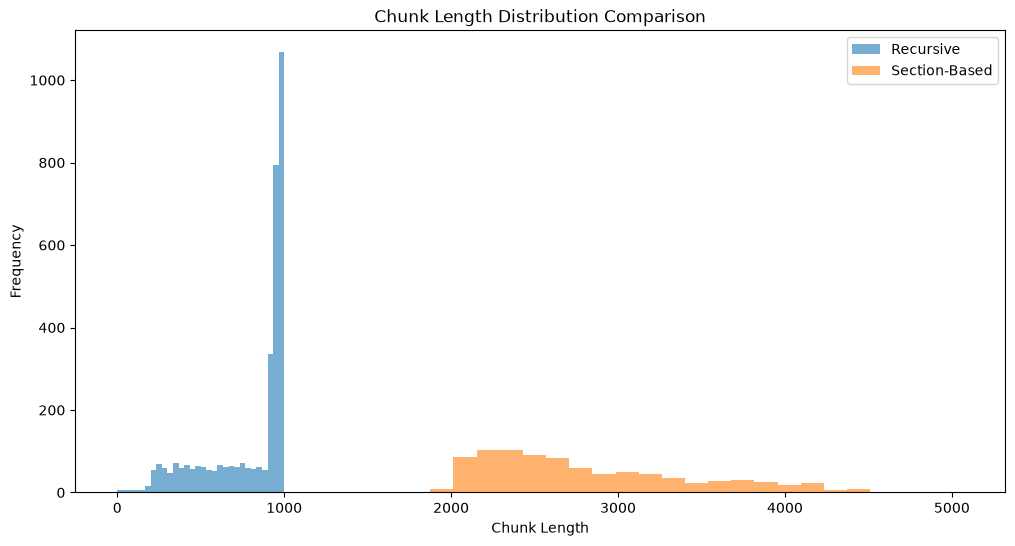

In [25]:
plt.figure(figsize=(12,6))

plt.hist(
    recursive_lengths,
    bins=30,
    alpha=0.6,
    label="Recursive"
)

plt.hist(
    section_lengths,
    bins=30,
    alpha=0.6,
    label="Section-Based"
)

plt.title(
    "Chunk Length Distribution Comparison"
)

plt.xlabel(
    "Chunk Length"
)

plt.ylabel(
    "Frequency"
)

plt.legend()

plt.savefig(
    "../screenshots/chunking/chunking_comparison.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

In [26]:
comparison_df.to_csv(
    "../screenshots/chunking/chunking_comparison.csv",
    index=False
)

print(
    "Comparison results exported."
)

Comparison results exported.


# Key Findings

## Recursive Chunking

Advantages:

- Smaller chunks
- More granular retrieval
- Faster processing
- Lower context size

Best For:

- Precision retrieval
- FAQ-style questions
- Focused information lookup

---

## Section-Based Chunking

Advantages:

- Larger context windows
- Preserves Oracle ERP business processes
- Fewer vector records
- Better procedural continuity

Best For:

- Business process explanations
- Oracle setup documentation
- End-to-end workflow retrieval

---

## Next Step

Proceed to:

### 05_MiniLM_Embeddings.ipynb

Pipeline 1 Embedding Strategy